# 07 · LSTM·GRU: 남길 정보와 바꿀 정보를 계산하기

**질문:** RNN에서 상태를 매번 tanh로 다시 쓰면 과거 정보의 미분도 긴 곱을 거칩니다. 상태를 덧셈으로 이어 주고, 남길 양을 데이터에 따라 결정할 수 있을까요?

LSTM 한 스텝 → 두 경로의 backward → GRU 한 스텝과 backward → 시간 반복 → 지연된 신호 기억을 만듭니다. 06의 RNN·BPTT를 먼저 확인하세요. LSTM과 GRU는 구조이고, 이번 학습 목적은 마지막 시각의 이진 분류입니다.

[그림 보조 파일](../../src/utils/architecture_plots.py) · [이전 RNN](06_rnn.ipynb) · [전체 경로](../../docs/CURRICULUM.md)

한 번에 끝내기 길면 1–3절(LSTM), 4절(GRU), 5–7절(시간 반복·실험·직접 변형)로 나누세요.

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.architecture_plots import plot_matrices, plot_curves
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· LSTM·GRU 준비 완료")

NumPy 2.3.5 · LSTM·GRU 준비 완료


## 1. LSTM의 두 상태와 세 게이트

$x\in\mathbb R^{N\times D}$, 이전 출력 상태 $h_{prev}$와 메모리 상태 $c_{prev}$는 $(N,H)$입니다. $u=[x,h_{prev}]$는 **열 방향 연결**이어서 $(N,D+H)$입니다.

$$[a_f,a_i,a_o,a_g]=uW+b,\quad W\in\mathbb R^{(D+H)\times4H}.$$
$$f=\sigma(a_f),\ i=\sigma(a_i),\ o=\sigma(a_o),\ g=\tanh(a_g),$$
$$c=f\odot c_{prev}+i\odot g,\qquad h=o\odot\tanh(c).$$

| 기호 | 계산상 역할 |
|---|---|
| $f$ forget gate | 이전 메모리를 얼마나 남길지 |
| $i$ input gate | 새 후보를 얼마나 넣을지 |
| $o$ output gate | 메모리를 출력에 얼마나 드러낼지 |
| $g$ candidate | 새로 넣을 값, 범위 $(-1,1)$ |

게이트는 사람이 붙인 0/1 명령이 아니라 학습 가능한 affine+sigmoid의 출력입니다. sigmoid는 $(0,1)$ 범위의 부드러운 스위치지만 **게이트들의 합이 1일 필요는 없습니다.** `np.split(a,4,axis=1)`은 너비를 네 묶음으로 나누며, 코드의 순서는 항상 `f,i,o,g`입니다.

아래는 forget gate를 가진, peephole 연결 없는 LSTM입니다. 초기 1997년 원형과 현대 구현의 모든 변형이 동일한 식인 것은 아닙니다.

In [2]:
def sigmoid(z):
    t = np.exp(-np.abs(z))
    return np.where(z >= 0, 1 / (1 + t), t / (1 + t))


def lstm_step(x, hprev, cprev, p):
    u = np.concatenate([x, hprev], axis=1)
    af, ai, ao, ag = np.split(u @ p["W"] + p["b"], 4, axis=1)
    f, i, o, g = sigmoid(af), sigmoid(ai), sigmoid(ao), np.tanh(ag)
    c = f * cprev + i * g
    h = o * np.tanh(c)
    return h, c, (u, cprev, f, i, o, g, c, x.shape[1])

In [3]:
hand_p = {"W": np.zeros((2, 4)), "b": np.array([0., 0., 0., np.arctanh(0.8)])}
hand_h, hand_c, hand_cache = lstm_step(np.zeros((1, 1)), np.zeros((1, 1)), np.array([[0.2]]), hand_p)
# np.arctanh(0.8)는 tanh를 적용하면 0.8이 되는 입력입니다.
np.testing.assert_allclose(hand_c, 0.5 * 0.2 + 0.5 * 0.8)
np.testing.assert_allclose(hand_h, 0.5 * np.tanh(0.5))
print("f=i=o=0.5, g=0.8 → c=", hand_c.item(), "h=", hand_h.item())

f=i=o=0.5, g=0.8 → c= 0.5 h= 0.23105857863000487


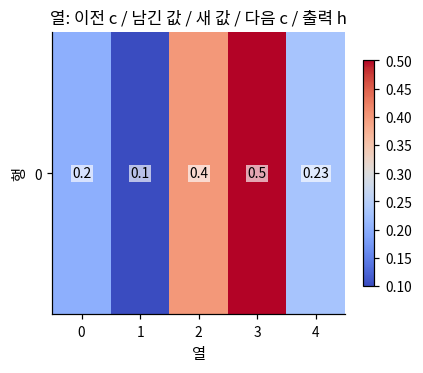

In [4]:
plot_matrices([np.array([[0.2, 0.5 * 0.2, 0.5 * 0.8, hand_c.item(), hand_h.item()]])],
              ["열: 이전 c / 남긴 값 / 새 값 / 다음 c / 출력 h"])

## 2. LSTM backward: c로 향하는 기울기를 먼저 합합니다

상류 입력을 $dh$, $dc_{future}$라 두면 $h=o\tanh(c)$에서
$$do=dh\odot\tanh(c),\qquad dc=dc_{future}+dh\odot o\odot(1-\tanh^2(c)).$$
$c=f c_{prev}+ig$의 네 입력으로 돌아갑니다.
$$df=dc\odot c_{prev},\quad dc_{prev}=dc\odot f,\quad di=dc\odot g,\quad dg=dc\odot i.$$
게이트의 비선형을 지나면
$$da_f=df\odot f(1-f),\quad da_i=di\odot i(1-i),\quad
 da_o=do\odot o(1-o),\quad da_g=dg\odot(1-g^2).$$
네 $da$를 forward와 같은 순서로 연결해 $dW=u^Tda$, $db=\sum_n da$, $du=daW^T$를 구합니다. $du$의 앞 $D$열은 $dx$, 뒤 $H$열은 $dh_{prev}$입니다. $dc_{prev}$는 별도의 상태 경로라서 따로 반환합니다.

In [5]:
def lstm_step_backward(dh, dc_future, cache, p):
    u, cprev, f, i, o, g, c, D = cache
    tanhc = np.tanh(c)
    do = dh * tanhc
    dc = dc_future + dh * o * (1 - tanhc ** 2)
    df, di, dg = dc * cprev, dc * g, dc * i
    da = np.concatenate([df * f * (1 - f), di * i * (1 - i),
                         do * o * (1 - o), dg * (1 - g ** 2)], axis=1)
    du = da @ p["W"].T
    grads = {"W": u.T @ da, "b": da.sum(axis=0)}
    return du[:, :D], du[:, D:], dc * f, grads


def check_lstm_step(candidate):
    rng = np.random.default_rng(71)
    x, h0, c0 = [rng.normal(size=(2, 2)) * 0.3 for _ in range(3)]
    p = {"W": rng.normal(size=(4, 8)) * 0.3, "b": rng.normal(size=8) * 0.2}
    h, c, cache = lstm_step(x, h0, c0, p)
    dh, dc = rng.normal(size=h.shape), rng.normal(size=c.shape)
    dx, dh0, dc0, grads = candidate(dh, dc, cache, p)
    def scalar():
        h, c, _ = lstm_step(x, h0, c0, p)
        return float(np.sum(h * dh) + np.sum(c * dc))
    errors = {}
    for name, value, grad in [("x", x, dx), ("h0", h0, dh0), ("c0", c0, dc0),
                              *[(k, v, grads[k]) for k, v in p.items()]]:
        errors[name] = rel_error(grad, numerical_gradient(scalar, value))
        assert np.isfinite(errors[name]) and errors[name] < 2e-6, (name, errors[name])
    return errors

In [6]:
lstm_step_errors = check_lstm_step(lstm_step_backward)
print("LSTM 한 스텝 최대 상대오차:", max(lstm_step_errors.values()))

LSTM 한 스텝 최대 상대오차: 2.1654197627094866e-10


## 3. 덧셈 경로는 무엇을 보장합니까?

다른 입력과 게이트를 고정한 **c의 직접 경로**에서는 $\partial c_t/\partial c_{t-1}=f_t$입니다. 이 경로만 따라가면 곱은 $\prod_t f_t$입니다. $f\approx1$이면 정보를 오래 전달할 수 있지만, $f<1$의 긴 곱은 여전히 줄어듭니다.

실제 모델의 전체 미분에는 $c\to h\to$ 다음 게이트로 이어지는 경로도 있습니다. 전체 Jacobian이 언제나 $\prod f$라거나 LSTM에서 기울기 소실이 완전히 사라진다고 말하면 틀립니다. 아래 실험은 $W=0$으로 게이트를 상수로 만든 **직접 경로만의 통제 예제**입니다.

In [7]:
delays = np.arange(1, 41)
retention = {}
for f in [0.5, 0.9, 0.99]:
    # log(f/(1-f))를 sigmoid에 넣으면 f가 됩니다.
    p_fixed = {"W": np.zeros((2, 4)), "b": np.array([np.log(f / (1 - f)), 0., 0., 0.])}
    c, h = np.ones((1, 1)), np.zeros((1, 1))
    values = []
    for _ in delays:
        h, c, _ = lstm_step(np.zeros((1, 1)), h, c, p_fixed)
        values.append(c.item())
    np.testing.assert_allclose(values, f ** delays)
    retention[f"f={f}"] = values

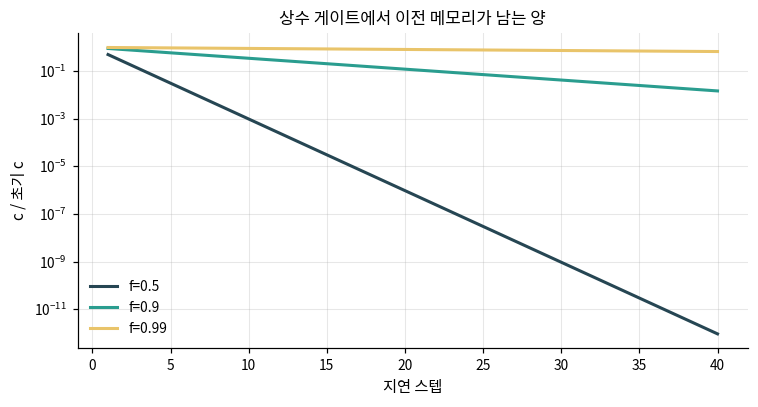

In [8]:
plot_curves(delays, retention, title="상수 게이트에서 이전 메모리가 남는 양", xlabel="지연 스텝",
            ylabel="c / 초기 c", logy=True)

## 4. GRU: 상태 하나에 남길 값과 새 값을 섞기

GRU에는 별도의 $c$가 없습니다. 이 노트북은 Cho 등의 관례를 따라 **z가 클수록 이전 상태를 유지**합니다.
$$z=\sigma([x,h_{prev}]W_z+b_z),\quad r=\sigma([x,h_{prev}]W_r+b_r),$$
$$q=[x,r\odot h_{prev}],\quad g=\tanh(qW_g+b_g),\quad
h=z\odot h_{prev}+(1-z)\odot g.$$

reset $r$는 후보를 만들 때 과거 상태를 얼마나 사용할지 조절합니다. 어떤 자료는 z의 역할을 반대로 정의하거나 reset을 행렬곱 뒤에 곱합니다. **기호 이름 대신 실제 수식과 곱 순서**를 비교해야 합니다. 여기서는 reset-before 형태입니다.

Backward를 곱·덧셈 순서대로 쓰면
$$dz=dh\odot(h_{prev}-g),\quad dg=dh\odot(1-z),\quad dh_{prev}^{direct}=dh\odot z.$$
후보의 tanh와 affine을 거쳐 얻은 $dq_h$에 대해 $dr=dq_h\odot h_{prev}$, $dh_{prev}^{candidate}=dq_h\odot r$입니다. 여기에 z·r의 affine 경로에서 온 $dh_{prev}$를 더해야 합니다.

In [9]:
def gru_step(x, hprev, p):
    u = np.concatenate([x, hprev], axis=1)
    z = sigmoid(u @ p["Wz"] + p["bz"])
    r = sigmoid(u @ p["Wr"] + p["br"])
    q = np.concatenate([x, r * hprev], axis=1)
    g = np.tanh(q @ p["Wg"] + p["bg"])
    h = z * hprev + (1 - z) * g
    return h, (u, q, hprev, z, r, g, x.shape[1])


def gru_step_backward(dh, cache, p):
    u, q, hprev, z, r, g, D = cache
    dz, dg = dh * (hprev - g), dh * (1 - z)
    dag = dg * (1 - g ** 2)
    dq = dag @ p["Wg"].T
    dr = dq[:, D:] * hprev
    dar, daz = dr * r * (1 - r), dz * z * (1 - z)
    du = dar @ p["Wr"].T + daz @ p["Wz"].T
    dx = dq[:, :D] + du[:, :D]
    dhprev = dh * z + dq[:, D:] * r + du[:, D:]
    grads = {"Wz": u.T @ daz, "bz": daz.sum(axis=0), "Wr": u.T @ dar, "br": dar.sum(axis=0),
             "Wg": q.T @ dag, "bg": dag.sum(axis=0)}
    return dx, dhprev, grads


def init_gates(kind, D, H, seed):
    rng = np.random.default_rng(seed)
    if kind == "LSTM":
        W = rng.normal(size=(D + H, 4 * H)) / np.sqrt(D + H)
        b = np.zeros(4 * H)
        b[:H] = 1.  # 입력·상태의 affine 항이 0일 때 forget gate가 sigmoid(1)
        return {"W": W, "b": b}
    return {key: value for gate in ["z", "r", "g"]
            for key, value in [("W" + gate, rng.normal(size=(D + H, H)) / np.sqrt(D + H)),
                               ("b" + gate, np.zeros(H))]}


def check_gru_step(candidate):
    rng = np.random.default_rng(74)
    x, h0 = rng.normal(size=(2, 2)), rng.normal(size=(2, 3))
    p = init_gates("GRU", 2, 3, 75)
    h, cache = gru_step(x, h0, p)
    dh = rng.normal(size=h.shape)
    dx, dh0, grads = candidate(dh, cache, p)
    scalar = lambda: float(np.sum(gru_step(x, h0, p)[0] * dh))
    errors = {}
    for name, value, grad in [("x", x, dx), ("h0", h0, dh0), *[(k, v, grads[k]) for k, v in p.items()]]:
        errors[name] = rel_error(grad, numerical_gradient(scalar, value))
        assert np.isfinite(errors[name]) and errors[name] < 2e-6, (name, errors[name])
    return errors

In [10]:
gru_step_errors = check_gru_step(gru_step_backward)
print("GRU 한 스텝 최대 상대오차:", max(gru_step_errors.values()))
# W=0, bias=0이면 z=r=0.5, g=0이므로 h=0.5*hprev입니다.
zero_gru = {k: np.zeros_like(v) for k, v in init_gates("GRU", 1, 1, 0).items()}
np.testing.assert_allclose(gru_step(np.array([[3.]]), np.array([[0.8]]), zero_gru)[0], 0.4)
print("GRU z가 이전 상태를 유지하는 손계산 통과")

GRU 한 스텝 최대 상대오차: 9.456371417325128e-10
GRU z가 이전 상태를 유지하는 손계산 통과


## 5. 한 스텝을 시간에 펼치기

`Hs[:,t]`, `Cs[:,t]`는 그 입력을 읽은 **뒤**의 상태입니다. 초기 상태는 따로 받아 첫 스텝에 전달합니다. `caches[t]`는 해당 스텝에서 backward에 필요한 배열을 보관합니다. 마지막 시각부터 돌아오면서 공유 파라미터의 미분을 누적합니다.

학습은 마지막 h만 사용하지만, 검사는 모든 h·c에 직접 손실을 붙입니다. 그래야 중간 상태 경로나 c의 상류 기울기를 빼먹는 오류를 잡을 수 있습니다. GRU에는 c가 없으므로 아래 공통 반복 인터페이스의 `Cs`, `dC`는 0을 채운 자리이며 학습 변수가 아닙니다.

In [11]:
def gated_forward(X, p, kind, h0=None, c0=None):
    assert kind in ("LSTM", "GRU")
    N, T, _ = X.shape
    H = p["W"].shape[1] // 4 if kind == "LSTM" else p["Wz"].shape[1]
    h = np.zeros((N, H)) if h0 is None else h0.copy()
    c = np.zeros((N, H)) if c0 is None else c0.copy()
    Hs, Cs = np.zeros((N, T, H)), np.zeros((N, T, H))
    caches = []
    for t in range(T):
        if kind == "LSTM":
            h, c, cache = lstm_step(X[:, t], h, c, p)
            Cs[:, t] = c
        else:
            h, cache = gru_step(X[:, t], h, p)
        Hs[:, t] = h
        caches.append(cache)
    return Hs, Cs, caches


def gated_backward(dH, dC, caches, p, kind, step_fn=None):
    if step_fn is None:
        step_fn = lstm_step_backward if kind == "LSTM" else gru_step_backward
    N, T, H = dH.shape
    D = caches[0][-1]
    dX = np.zeros((N, T, D))
    dh, dc = np.zeros((N, H)), np.zeros((N, H))
    grads = {k: np.zeros_like(v) for k, v in p.items()}
    if kind == "GRU":
        assert np.all(dC == 0), "GRU에는 별도의 c 상태가 없습니다"
    for t in reversed(range(T)):
        if kind == "LSTM":
            dX[:, t], dh, dc, local = step_fn(dH[:, t] + dh, dC[:, t] + dc, caches[t], p)
        else:
            dX[:, t], dh, local = step_fn(dH[:, t] + dh, caches[t], p)
        for key in grads:
            grads[key] += local[key]
    return dX, dh, dc, grads


def check_gated_sequence(kind, step_fn=None):
    rng = np.random.default_rng(76)
    X = rng.normal(size=(1, 3, 2)) * 0.3
    h0, c0 = rng.normal(size=(1, 2)) * 0.2, rng.normal(size=(1, 2)) * 0.2
    p = init_gates(kind, 2, 2, 77)
    H, C, caches = gated_forward(X, p, kind, h0, c0)
    dH = rng.normal(size=H.shape)
    dC = rng.normal(size=C.shape) if kind == "LSTM" else np.zeros_like(C)
    dx, dh0, dc0, grads = gated_backward(dH, dC, caches, p, kind, step_fn)
    def scalar():
        H, C, _ = gated_forward(X, p, kind, h0, c0)
        return float(np.sum(H * dH) + np.sum(C * dC))
    entries = [("X", X, dx), ("h0", h0, dh0)] + [(k, v, grads[k]) for k, v in p.items()]
    if kind == "LSTM":
        entries.append(("c0", c0, dc0))
    errors = {k: rel_error(g, numerical_gradient(scalar, v)) for k, v, g in entries}
    assert all(np.isfinite(e) and e < 2e-6 for e in errors.values()), errors
    return errors

In [12]:
sequence_errors = {kind: check_gated_sequence(kind) for kind in ["LSTM", "GRU"]}
for kind, errors in sequence_errors.items():
    print(kind, "3스텝 전체 미분 최대 상대오차:", max(errors.values()))

LSTM 3스텝 전체 미분 최대 상대오차: 3.961704369723117e-10
GRU 3스텝 전체 미분 최대 상대오차: 3.6187939142249692e-09


## 6. 완성 실험: 처음의 부호를 12스텝 뒤에 답하기

입력은 `(N,T,2)`입니다. 첫 채널에는 첫 시각의 ±1 신호와 이후 작은 잡음이 들어갑니다. 두 번째 채널은 첫 시각에만 1인 쓰기 표시입니다. 마지막 h에 선형 head를 붙여 처음 신호가 양수인지 예측합니다.

훈련 96개와 검증 64개는 별도 난수로 생성합니다. 모든 시퀀스 길이는 12입니다. 이 작은 실험은 게이트·상태·손실의 연결을 확인하며, 임의 길이 기억 능력이나 두 구조의 성능 순위를 증명하지 않습니다. 동일한 폭이어도 LSTM은 네 묶음, GRU는 세 묶음의 가중치를 가지므로 파라미터 수도 다릅니다.

이진 CE는 $L=\frac1N\sum_n[\log(1+e^{z_n})-y_nz_n]$, $dz=(\sigma(z)-y)/N$입니다. clipping과 Adam은 04·06에서 한 계산을 그대로 본문에 사용합니다.

In [13]:
def memory_data(n, T, seed):
    rng = np.random.default_rng(seed)
    y = np.arange(n) % 2
    rng.shuffle(y)
    X = np.zeros((n, T, 2))
    X[:, :, 0] = rng.normal(0, 0.12, (n, T))
    X[:, 0, 0] = 2 * y - 1
    X[:, 0, 1] = 1
    return X, y


def memory_loss(X, y, p, head, kind):
    H, C, caches = gated_forward(X, p, kind)
    logits = H[:, -1] @ head["W"] + head["b"]
    target = y[:, None]
    loss = np.mean(np.logaddexp(0, logits) - target * logits)
    dz = (sigmoid(logits) - target) / len(y)
    dhead = {"W": H[:, -1].T @ dz, "b": dz.sum(axis=0)}
    dH = np.zeros_like(H)
    dH[:, -1] = dz @ head["W"].T
    dX, _, _, grads = gated_backward(dH, np.zeros_like(C), caches, p, kind)
    return loss, logits[:, 0], grads, dhead, dX


def adam_step(p, grads, state, step, lr=0.02):
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]
        v = 0.999 * v + 0.001 * grads[key] ** 2
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)


def train_memory(kind, X, y, Xv, yv, steps=350, width=8):
    p = init_gates(kind, 2, width, 78)
    rng = np.random.default_rng(79)
    head = {"W": rng.normal(size=(width, 1)) / np.sqrt(width), "b": np.zeros(1)}
    states = [{k: (np.zeros_like(v), np.zeros_like(v)) for k, v in params.items()} for params in [p, head]]
    history = {"step": [], "train": [], "valid": []}
    for step in range(steps + 1):
        loss, logits, grads, dhead, _ = memory_loss(X, y, p, head, kind)
        if step % 50 == 0 or step == steps:
            vl, vz, *_ = memory_loss(Xv, yv, p, head, kind)
            history["step"].append(step)
            history["train"].append(loss)
            history["valid"].append(vl)
        if step == steps:
            break
        norm = np.sqrt(sum(np.sum(g * g) for g in [*grads.values(), *dhead.values()]))
        scale = min(1., 1. / (norm + 1e-12))
        for params, gradients, state in zip([p, head], [grads, dhead], states):
            adam_step(params, {k: g * scale for k, g in gradients.items()}, state, step + 1)
    accuracy = np.mean((vz > 0) == yv)
    return p, head, history, accuracy

In [14]:
X_train, y_train = memory_data(96, 12, 701)
X_valid, y_valid = memory_data(64, 12, 702)
trained = {}
for kind in ["LSTM", "GRU"]:
    trained[kind] = train_memory(kind, X_train, y_train, X_valid, y_valid)
    p, head, hist, accuracy = trained[kind]
    count = sum(v.size for v in [*p.values(), *head.values()])
    print(f"{kind}: 파라미터 {count}, 학습 BCE {hist['train'][0]:.6f} → {hist['train'][-1]:.6f}, "
          f"검증 BCE {hist['valid'][-1]:.6f}, 검증 정확도 {accuracy:.1%}")
    assert hist["train"][-1] < 0.1 and accuracy > 0.9

LSTM: 파라미터 361, 학습 BCE 0.689228 → 0.000505, 검증 BCE 0.000504, 검증 정확도 100.0%


GRU: 파라미터 273, 학습 BCE 0.695544 → 0.000258, 검증 BCE 0.000258, 검증 정확도 100.0%


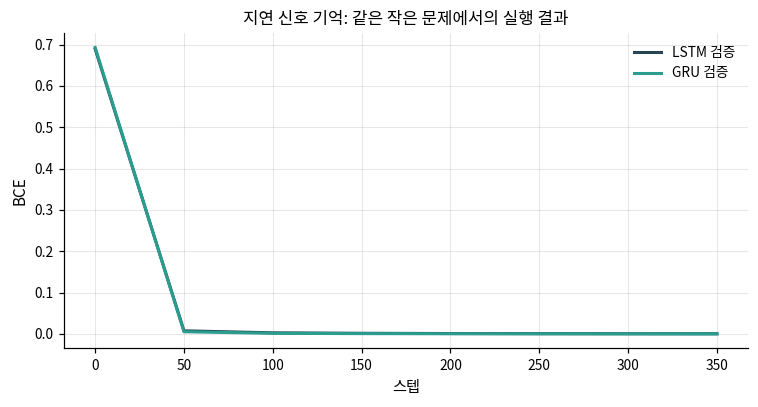

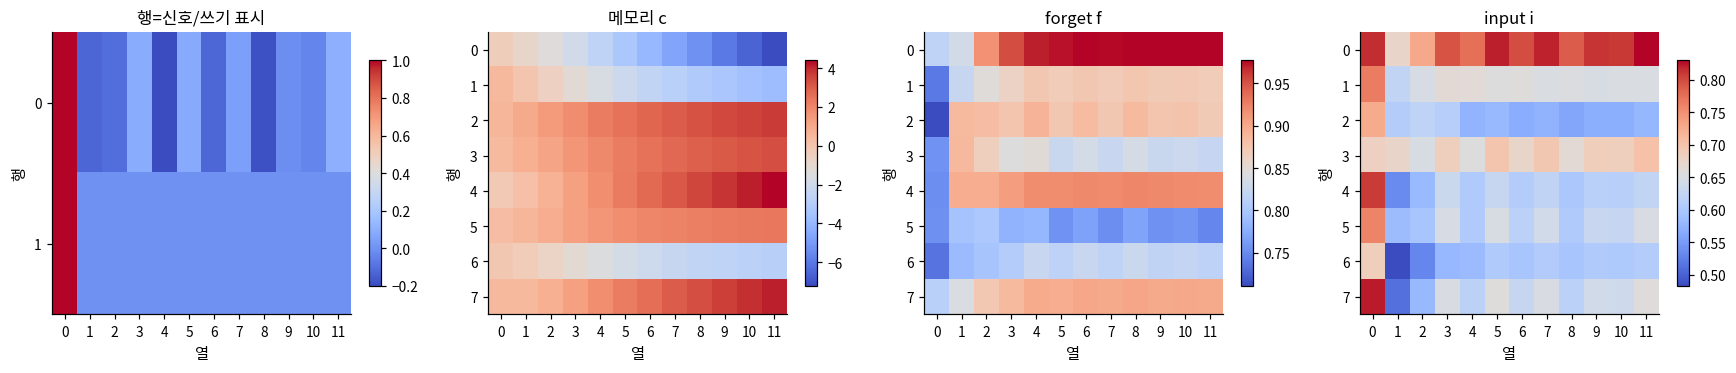

In [15]:
plot_curves(trained["LSTM"][2]["step"],
            {f"{kind} 검증": result[2]["valid"] for kind, result in trained.items()},
            title="지연 신호 기억: 같은 작은 문제에서의 실행 결과", ylabel="BCE")
p_lstm = trained["LSTM"][0]
Hs, Cs, caches = gated_forward(X_valid[:1], p_lstm, "LSTM")
forget = np.stack([cache[2][0] for cache in caches])
inputs = np.stack([cache[3][0] for cache in caches])
plot_matrices([X_valid[0].T, Cs[0].T, forget.T, inputs.T],
              ["행=신호/쓰기 표시", "메모리 c", "forget f", "input i"], annotate=False)

게이트 그림은 학습된 배열의 관측입니다. 모든 좌표가 같은 시점에 완전히 열리거나 닫힐 필요는 없습니다. 특정 좌표에 '기억 뉴런'이라는 의미를 붙이기 전에 입력 부호·잡음·길이를 바꾸어 같은 반응이 유지되는지 확인해야 합니다.

## 7. 직접 변형과 오답 검출

새 셀에 자신의 `my_lstm_step_backward(dh, dc_future, cache, p)` 또는 `my_gru_step_backward(dh, cache, p)`를 쓰세요. 다음 두 단계를 모두 진행합니다.

1. `check_lstm_step(my_lstm_step_backward)`와 `check_gated_sequence("LSTM", my_lstm_step_backward)`처럼 **같은 후보를 한 스텝·여러 스텝에 전달**하세요. GRU도 같은 방식입니다.
2. forget bias를 1→0으로 바꾸고 12스텝 학습을 다시 실행하세요. 입력·이전 상태의 affine 항이 0일 때 bias만으로 정해지는 유지량이 sigmoid(1)≈0.731에서 0.5로 바뀝니다. 실제 gate는 입력·상태에도 의존하므로, 초기 샘플별 값과 학습 후 값은 별도로 기록하세요.
3. 학습한 모델을 `memory_data(64, 24, 703)`에 적용하세요. 추가 학습 없이 길이만 두 배로 늘린 결과가 어떻게 달라집니까? 짧은 학습 성공과 길이 밖 기억을 구분하세요.

아래는 c의 상류 경로를 잘라 버린 실제 오답입니다. 검사기가 거부해야 합니다.

In [16]:
def wrong_drop_cell_gradient(dh, dc_future, cache, p):
    return lstm_step_backward(dh, np.zeros_like(dc_future), cache, p)

In [17]:
try:
    check_lstm_step(wrong_drop_cell_gradient)
except AssertionError:
    print("의도적 오답 검출: c의 별도 상류 기울기 누락")
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")
X_long, y_long = memory_data(64, 24, 703)
for kind, (p, head, _, _) in trained.items():
    loss, z, *_ = memory_loss(X_long, y_long, p, head, kind)
    print(f"추가 갱신 없는 길이 24 {kind}: BCE {loss:.6f}, 정확도 {np.mean((z > 0) == y_long):.1%}")

의도적 오답 검출: c의 별도 상류 기울기 누락
추가 갱신 없는 길이 24 LSTM: BCE 0.000503, 정확도 100.0%
추가 갱신 없는 길이 24 GRU: BCE 0.000257, 정확도 100.0%


### 준비도 확인

- **설명:** LSTM의 h·c와 세 게이트, GRU의 reset·update가 실제로 곱하는 대상을 설명할 수 있습니까?
- **수식:** c로 들어온 두 미분을 더하고 GRU의 직접·후보·게이트 경로를 모두 셀 수 있습니까?
- **구현:** 네 묶음의 순서와 concat/split 축을 맞추며 초기 상태까지 미분할 수 있습니까?
- **변형:** forget bias·지연 길이를 바꾸고, 직접 경로의 곱과 전체 미분을 구분할 수 있습니까?

[LSTM 원전, Hochreiter·Schmidhuber 1997](https://www.bioinf.jku.at/publications/older/2604.pdf), [LSTM 변형과 수식, Greff 등](https://arxiv.org/abs/1503.04069), [GRU, Cho 등 2.3절](https://arxiv.org/abs/1406.1078)을 참고할 수 있습니다. 여기서는 위에서 명시한 peephole 없는 LSTM과 reset-before GRU를 구현했습니다.

다음은 [08 Attention](08_attention.ipynb)입니다. 과거를 한 상태에만 넣는 대신, 필요한 위치를 점수로 선택해 읽습니다.